In [1]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D,MaxPooling2D,AveragePooling2D,Flatten,Dense,Dropout,GlobalAveragePooling2D,Input,concatenate,Resizing
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import seaborn as sns

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

In [1]:
plt.rcParams["font.family"]="Times New Roman"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1656s 10us/step


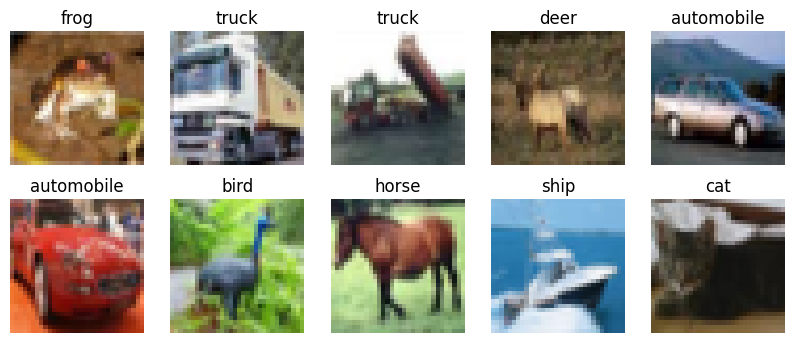

In [5]:
(x_train_raw,y_train_raw),(x_test_raw,y_test_raw)=tf.keras.datasets.cifar10.load_data()
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
plt.figure(figsize=(10,4))
for i in range(10):
 plt.subplot(2,5,i+1)
 plt.imshow(x_train_raw[i])
 plt.title(classes[int(y_train_raw[i][0])])
 plt.axis("off")
plt.savefig("images/sample_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [6]:
x_train=x_train_raw.astype("float32")/255.0
x_test=x_test_raw.astype("float32")/255.0

x_train_main=x_train[:45000]
x_val=x_train[45000:]
y_train_main=y_train_raw[:45000].flatten()
y_val=y_train_raw[45000:].flatten()
y_test=y_test_raw.flatten()

y_train_cat=to_categorical(y_train_main,num_classes=10)
y_val_cat=to_categorical(y_val,num_classes=10)
y_test_cat=to_categorical(y_test,num_classes=10)

print("Training Images:",x_train_main.shape)
print("Validation Images:",x_val.shape)
print("Testing Images:",x_test.shape)
print("Number of Classes:",10)
print("Image Size:",x_train.shape[1:])
print("Normalization:Pixel values scaled to [0,1]")
print("Batch Size:",32)

Training Images: (45000, 32, 32, 3)
Validation Images: (5000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)
Number of Classes: 10
Image Size: (32, 32, 3)
Normalization:Pixel values scaled to [0,1]
Batch Size: 32


In [7]:
input_shape=(32,32,3)

base_model=VGG16(weights="imagenet",include_top=False,input_shape=input_shape)

for layer in base_model.layers:
 layer.trainable=False

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(256,activation="relu")(x)
output=Dense(10,activation="softmax")(x)

model=Model(inputs=base_model.input,outputs=output)

total_parameters=model.count_params()
trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

print("Total Parameters:",total_parameters)
print("Trainable Parameters:",trainable_parameters)
print("Non Trainable Parameters:",non_trainable_parameters)

model.compile(optimizer=Adam(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

I0000 00:00:1787924411.322997      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787924411.325790      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total Parameters: 14848586
Trainable Parameters: 133898
Non Trainable Parameters: 14714688


In [8]:
start_time=time.time()

history=model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

initial_training_time=time.time()-start_time

print("Initial Training Time:",initial_training_time)
print("Final Training Accuracy:",history.history["accuracy"][-1])
print("Final Validation Accuracy:",history.history["val_accuracy"][-1])

Epoch 1/5
  25/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.1302 - loss: 2.3229

I0000 00:00:1787924419.360959     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.5252 - loss: 1.3598 - val_accuracy: 0.5714 - val_loss: 1.2444
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5884 - loss: 1.1765 - val_accuracy: 0.5882 - val_loss: 1.1847
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6137 - loss: 1.1079 - val_accuracy: 0.5968 - val_loss: 1.1589
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6336 - loss: 1.0556 - val_accuracy: 0.6022 - val_loss: 1.1502
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6482 - loss: 1.0102 - val_accuracy: 0.6090 - val_loss: 1.1366
Initial Training Time: 64.66667985916138
Final Training Accuracy: 0.6481999754905701
Final Validation Accuracy: 0.609000027179718


In [9]:
for layer in base_model.layers:
 if layer.name.startswith("block5"):
  layer.trainable=True
 else:
  layer.trainable=False

fine_trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
fine_non_trainable_parameters=sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights)

model.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

start_time=time.time()

fine_history=model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

fine_tuning_time=time.time()-start_time

print("Fine Tuning Time:",fine_tuning_time)
print("Fine Tuned Training Accuracy:",fine_history.history["accuracy"][-1])
print("Fine Tuned Validation Accuracy:",fine_history.history["val_accuracy"][-1])
print("Fine Tuned Trainable Parameters:",fine_trainable_parameters)
print("Fine Tuned Non Trainable Parameters:",fine_non_trainable_parameters)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.6485 - loss: 1.0065 - val_accuracy: 0.6906 - val_loss: 0.8834
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.7432 - loss: 0.7286 - val_accuracy: 0.7158 - val_loss: 0.8356
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8044 - loss: 0.5487 - val_accuracy: 0.7064 - val_loss: 0.9459
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8542 - loss: 0.4113 - val_accuracy: 0.7034 - val_loss: 1.0817
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8850 - loss: 0.3176 - val_accuracy: 0.6904 - val_loss: 1.2887
Fine Tuning Time: 93.27568340301514
Fine Tuned Training Accuracy: 0.8850222229957581
Fine Tuned Validation Accuracy: 0.6904000043869019
Fine Tuned Trainable Parameters: 7213322
Fine Tuned Non Trainable Parameters: 7635264


In [10]:
train_acc=history.history["accuracy"]+fine_history.history["accuracy"]
val_acc=history.history["val_accuracy"]+fine_history.history["val_accuracy"]
train_loss=history.history["loss"]+fine_history.history["loss"]
val_loss=history.history["val_loss"]+fine_history.history["val_loss"]

epochs_range=range(1,len(train_acc)+1)
finetune_start=len(history.history["accuracy"])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


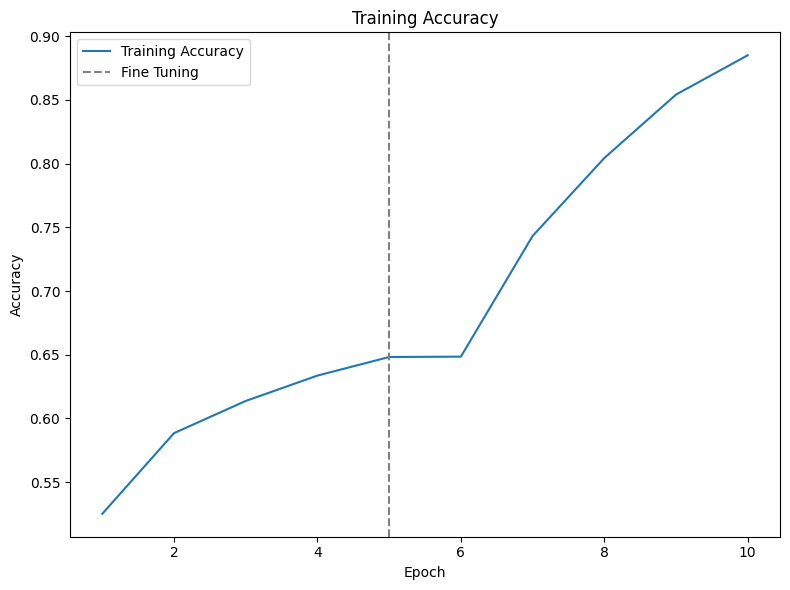

In [11]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,train_acc,label="Training Accuracy")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("images/training_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


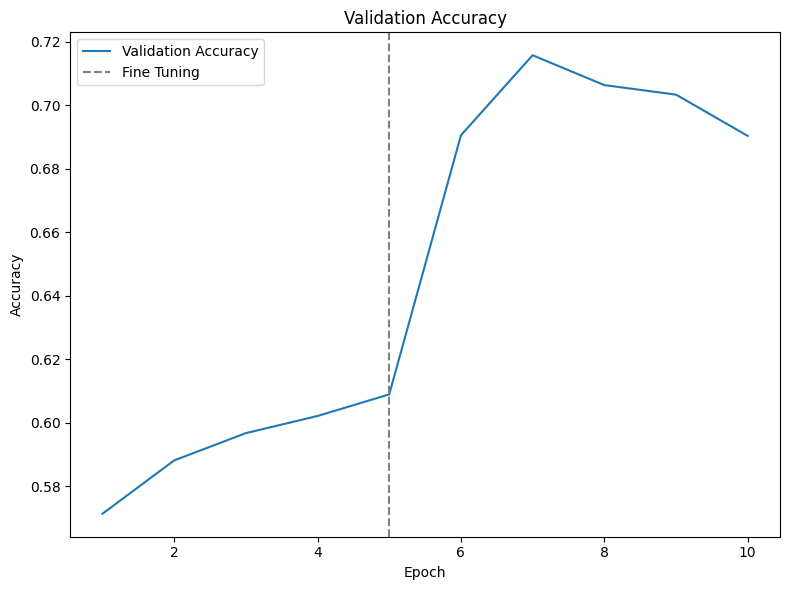

In [12]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,val_acc,label="Validation Accuracy")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("images/validation_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


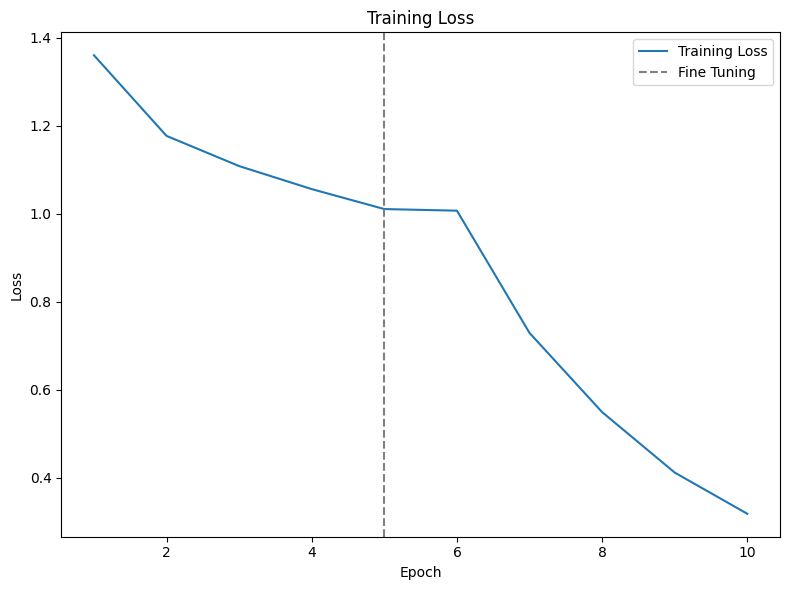

In [13]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,train_loss,label="Training Loss")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/training_loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


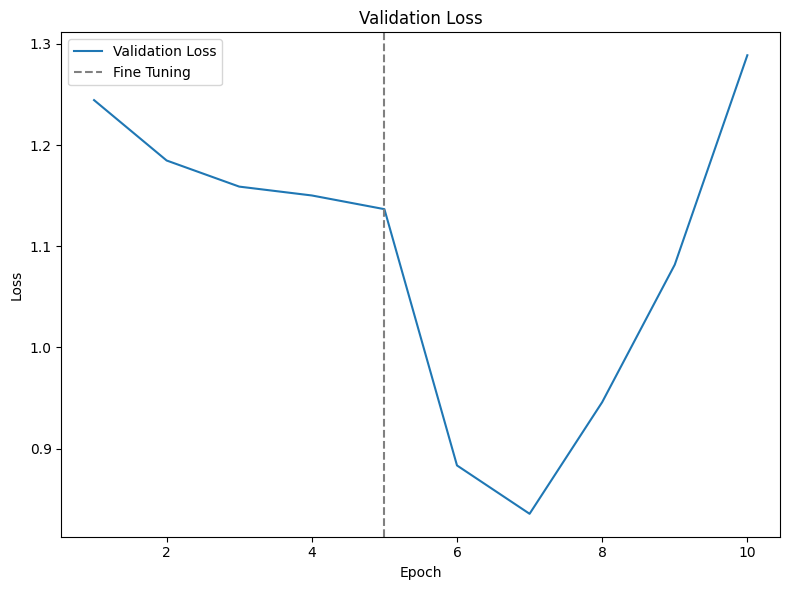

In [14]:
plt.figure(figsize=(8,6))
plt.plot(epochs_range,val_loss,label="Validation Loss")
plt.axvline(x=finetune_start,color="gray",linestyle="--",label="Fine Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/validation_loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [15]:
test_start=time.time()

test_loss,test_accuracy=model.evaluate(x_test,y_test_cat,batch_size=32,verbose=0)

test_time=time.time()-test_start

y_pred_prob=model.predict(x_test,batch_size=32,verbose=0)
y_pred=np.argmax(y_pred_prob,axis=1)

accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred,average="weighted")
recall=recall_score(y_test,y_pred,average="weighted")
f1=f1_score(y_test,y_pred,average="weighted")

print("Test Loss:",test_loss)
print("Test Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)
print("Test Evaluation Time:",test_time)

Test Loss: 1.3036593198776245
Test Accuracy: 0.6782
Precision: 0.7057577436668193
Recall: 0.6782
F1-score: 0.6769336575407191
Test Evaluation Time: 4.237046003341675


In [16]:
initial_val_accuracy=max(history.history["val_accuracy"])
finetuned_val_accuracy=max(fine_history.history["val_accuracy"])

print("Best Validation Accuracy Before Fine Tuning:",initial_val_accuracy*100)
print("Best Validation Accuracy After Fine Tuning:",finetuned_val_accuracy*100)
print("Improvement:",(finetuned_val_accuracy-initial_val_accuracy)*100)

Best Validation Accuracy Before Fine Tuning: 60.9000027179718
Best Validation Accuracy After Fine Tuning: 71.57999873161316
Improvement: 10.679996013641357


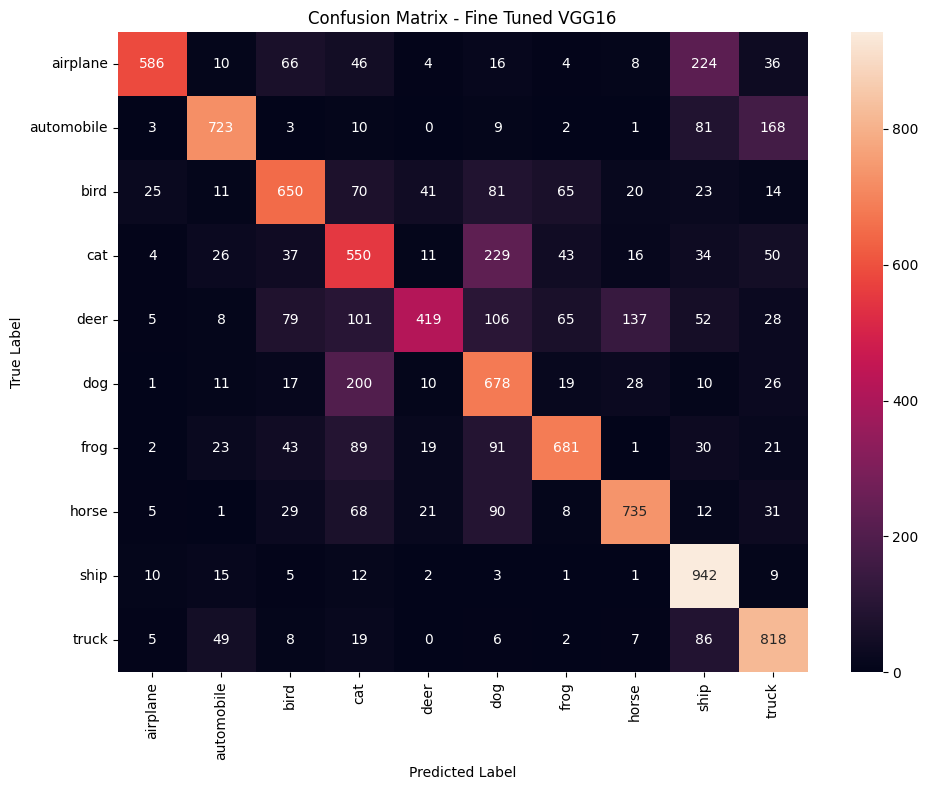

In [17]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fine Tuned VGG16")
plt.tight_layout()
plt.savefig("images/confusion_matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [18]:
print(classification_report(y_test,y_pred,target_names=classes))

              precision    recall  f1-score   support

    airplane       0.91      0.59      0.71      1000
  automobile       0.82      0.72      0.77      1000
        bird       0.69      0.65      0.67      1000
         cat       0.47      0.55      0.51      1000
        deer       0.80      0.42      0.55      1000
         dog       0.52      0.68      0.59      1000
        frog       0.77      0.68      0.72      1000
       horse       0.77      0.73      0.75      1000
        ship       0.63      0.94      0.76      1000
       truck       0.68      0.82      0.74      1000

    accuracy                           0.68     10000
   macro avg       0.71      0.68      0.68     10000
weighted avg       0.71      0.68      0.68     10000



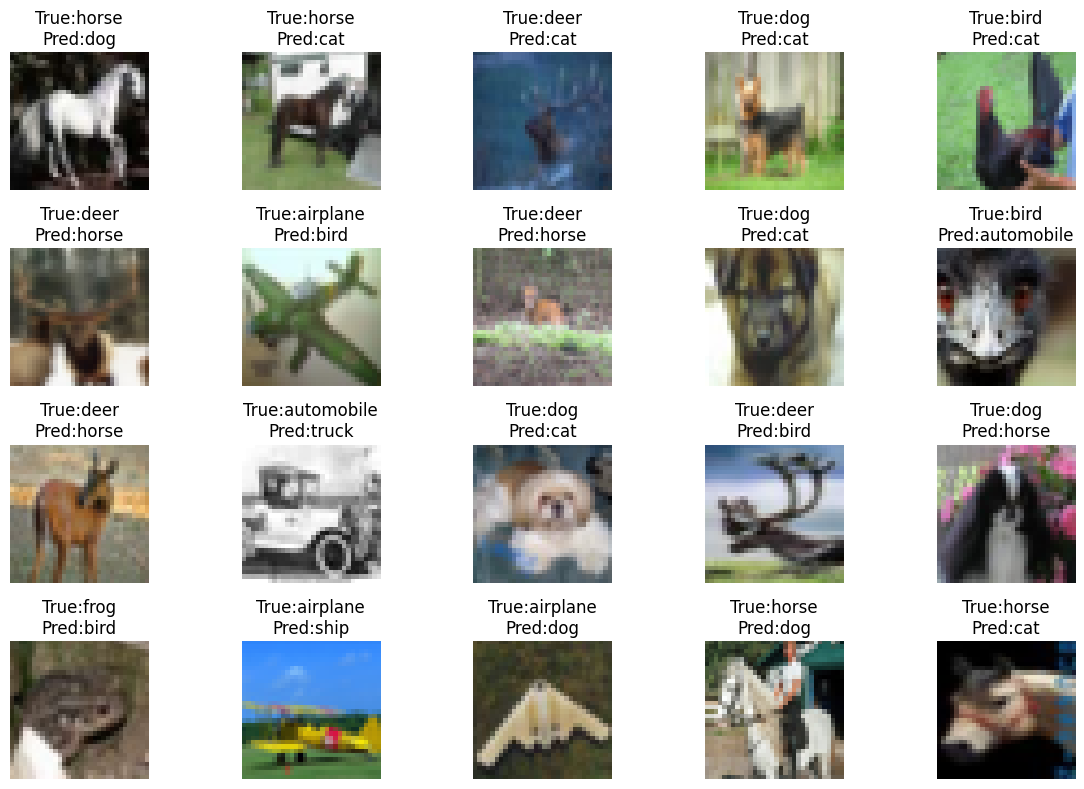

In [19]:
misclassified=np.where(y_test!=y_pred)[0]

plt.figure(figsize=(12,8))

for i,index in enumerate(misclassified[:20]):
 plt.subplot(4,5,i+1)
 plt.imshow(x_test[index])
 plt.title("True:"+classes[y_test[index]]+"\nPred:"+classes[y_pred[index]])
 plt.axis("off")

plt.tight_layout()
plt.savefig("images/misclassified_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [20]:
print("FINAL RESULTS")
print("Training Accuracy:",history.history["accuracy"][-1])
print("Validation Accuracy:",history.history["val_accuracy"][-1])
print("Testing Accuracy:",test_accuracy)
print("Test Loss:",test_loss)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)
print("Initial Training Time:",initial_training_time)
print("Fine Tuning Time:",fine_tuning_time)
print("Total Parameters:",total_parameters)
print("Initial Trainable Parameters:",trainable_parameters)
print("Fine Tuned Trainable Parameters:",fine_trainable_parameters)
print("Fine Tuned Non Trainable Parameters:",fine_non_trainable_parameters)
print("Fine Tuned Validation Accuracy:",fine_history.history["val_accuracy"][-1])

FINAL RESULTS
Training Accuracy: 0.6481999754905701
Validation Accuracy: 0.609000027179718
Testing Accuracy: 0.6782000064849854
Test Loss: 1.3036593198776245
Precision: 0.7057577436668193
Recall: 0.6782
F1-score: 0.6769336575407191
Initial Training Time: 64.66667985916138
Fine Tuning Time: 93.27568340301514
Total Parameters: 14848586
Initial Trainable Parameters: 133898
Fine Tuned Trainable Parameters: 7213322
Fine Tuned Non Trainable Parameters: 7635264
Fine Tuned Validation Accuracy: 0.6904000043869019


In [23]:
import os
import gc
from tensorflow.keras.applications import InceptionV3,ResNet50
from tensorflow.keras import backend as K

os.makedirs("images",exist_ok=True)

all_results={}
all_results["VGG16"]={"parameters":total_parameters,"accuracy":accuracy*100,"training_time":initial_training_time+fine_tuning_time}

In [24]:
K.clear_session()
gc.collect()

def build_lenet5():
 inputs=Input(shape=(32,32,3))
 x=Conv2D(6,(5,5),activation="relu",padding="same")(inputs)
 x=AveragePooling2D(pool_size=(2,2))(x)
 x=Conv2D(16,(5,5),activation="relu")(x)
 x=AveragePooling2D(pool_size=(2,2))(x)
 x=Flatten()(x)
 x=Dense(120,activation="relu")(x)
 x=Dense(84,activation="relu")(x)
 outputs=Dense(10,activation="softmax")(x)
 model=Model(inputs=inputs,outputs=outputs)
 return model

lenet_model=build_lenet5()
lenet_model.compile(optimizer=Adam(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

lenet_total_parameters=lenet_model.count_params()

start_time=time.time()

lenet_history=lenet_model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=10,
 verbose=1
)

lenet_training_time=time.time()-start_time

print("LeNet-5 Training Time:",lenet_training_time)
print("LeNet-5 Total Parameters:",lenet_total_parameters)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4068 - loss: 1.6288 - val_accuracy: 0.4810 - val_loss: 1.4155
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5192 - loss: 1.3338 - val_accuracy: 0.5424 - val_loss: 1.2648
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5704 - loss: 1.2079 - val_accuracy: 0.5838 - val_loss: 1.1693
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6049 - loss: 1.1128 - val_accuracy: 0.6076 - val_loss: 1.1096
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6307 - loss: 1.0430 - val_accuracy: 0.6186 - val_loss: 1.0850
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6498 - loss: 0.9883 - val_accuracy: 0.6198 - val_loss: 1.0768
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6662 - loss: 0.9404 - val_accuracy: 0.6214 - val_loss: 1.0857
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6835 - loss: 0.8996 -

In [25]:
lenet_test_loss,lenet_test_accuracy=lenet_model.evaluate(x_test,y_test_cat,batch_size=32,verbose=0)

lenet_y_pred_prob=lenet_model.predict(x_test,batch_size=32,verbose=0)
lenet_y_pred=np.argmax(lenet_y_pred_prob,axis=1)

lenet_accuracy=accuracy_score(y_test,lenet_y_pred)
lenet_precision=precision_score(y_test,lenet_y_pred,average="weighted")
lenet_recall=recall_score(y_test,lenet_y_pred,average="weighted")
lenet_f1=f1_score(y_test,lenet_y_pred,average="weighted")

print("LeNet-5 Test Accuracy:",lenet_accuracy)
print("LeNet-5 Precision:",lenet_precision)
print("LeNet-5 Recall:",lenet_recall)
print("LeNet-5 F1-score:",lenet_f1)

all_results["LeNet-5"]={"parameters":lenet_total_parameters,"accuracy":lenet_accuracy*100,"training_time":lenet_training_time}

del lenet_model
K.clear_session()
gc.collect()

LeNet-5 Test Accuracy: 0.6069
LeNet-5 Precision: 0.613461208950261
LeNet-5 Recall: 0.6069
LeNet-5 F1-score: 0.6029197950771755


0

In [27]:
from tensorflow.keras.layers import BatchNormalization
def build_alexnet():
 inputs=Input(shape=(32,32,3))
 x=Conv2D(96,(3,3),strides=1,padding="same",activation="relu")(inputs)
 x=BatchNormalization()(x)
 x=MaxPooling2D((2,2))(x)
 x=Conv2D(256,(3,3),padding="same",activation="relu")(x)
 x=BatchNormalization()(x)
 x=MaxPooling2D((2,2))(x)
 x=Conv2D(384,(3,3),padding="same",activation="relu")(x)
 x=BatchNormalization()(x)
 x=Conv2D(384,(3,3),padding="same",activation="relu")(x)
 x=BatchNormalization()(x)
 x=Conv2D(256,(3,3),padding="same",activation="relu")(x)
 x=BatchNormalization()(x)
 x=MaxPooling2D((2,2))(x)
 x=Flatten()(x)
 x=Dense(1024,activation="relu")(x)
 x=BatchNormalization()(x)
 x=Dropout(0.5)(x)
 x=Dense(1024,activation="relu")(x)
 x=BatchNormalization()(x)
 x=Dropout(0.5)(x)
 outputs=Dense(10,activation="softmax")(x)
 model=Model(inputs=inputs,outputs=outputs)
 return model

alexnet_model=build_alexnet()
alexnet_model.compile(optimizer=Adam(learning_rate=0.0005),loss="categorical_crossentropy",metrics=["accuracy"])

alexnet_total_parameters=alexnet_model.count_params()

start_time=time.time()

alexnet_history=alexnet_model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=10,
 verbose=1
)

alexnet_training_time=time.time()-start_time

print("AlexNet Training Time:",alexnet_training_time)
print("AlexNet Total Parameters:",alexnet_total_parameters)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.4341 - loss: 1.8096 - val_accuracy: 0.5642 - val_loss: 1.2633
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6310 - loss: 1.0696 - val_accuracy: 0.6396 - val_loss: 1.0730
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7196 - loss: 0.8219 - val_accuracy: 0.7158 - val_loss: 0.8458
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7739 - loss: 0.6570 - val_accuracy: 0.6508 - val_loss: 1.1501
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8236 - loss: 0.5129 - val_accuracy: 0.7362 - val_loss: 0.7956
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.8682 - loss: 0.3800 - val_accuracy: 0.7462 - val_loss: 0.8471
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.9070 - loss: 0.2713 - val_accuracy: 0.7066 - val_loss: 1.2175
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.9275 -

In [28]:
alexnet_test_loss,alexnet_test_accuracy=alexnet_model.evaluate(x_test,y_test_cat,batch_size=32,verbose=0)

alexnet_y_pred_prob=alexnet_model.predict(x_test,batch_size=32,verbose=0)
alexnet_y_pred=np.argmax(alexnet_y_pred_prob,axis=1)

alexnet_accuracy=accuracy_score(y_test,alexnet_y_pred)
alexnet_precision=precision_score(y_test,alexnet_y_pred,average="weighted")
alexnet_recall=recall_score(y_test,alexnet_y_pred,average="weighted")
alexnet_f1=f1_score(y_test,alexnet_y_pred,average="weighted")

print("AlexNet Test Accuracy:",alexnet_accuracy)
print("AlexNet Precision:",alexnet_precision)
print("AlexNet Recall:",alexnet_recall)
print("AlexNet F1-score:",alexnet_f1)

all_results["AlexNet"]={"parameters":alexnet_total_parameters,"accuracy":alexnet_accuracy*100,"training_time":alexnet_training_time}

del alexnet_model
K.clear_session()
gc.collect()

AlexNet Test Accuracy: 0.7453
AlexNet Precision: 0.7601486022476427
AlexNet Recall: 0.7453
AlexNet F1-score: 0.7428085446724157


0

In [29]:
inception_inputs=Input(shape=(32,32,3))
inception_resized=Resizing(75,75)(inception_inputs)
inception_base=InceptionV3(weights="imagenet",include_top=False,input_tensor=inception_resized)

for layer in inception_base.layers:
 layer.trainable=False

x=inception_base.output
x=GlobalAveragePooling2D()(x)
x=Dense(256,activation="relu")(x)
googlenet_outputs=Dense(10,activation="softmax")(x)

googlenet_model=Model(inputs=inception_inputs,outputs=googlenet_outputs)

googlenet_total_parameters=googlenet_model.count_params()

googlenet_model.compile(optimizer=Adam(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

start_time=time.time()

googlenet_history=googlenet_model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

googlenet_initial_time=time.time()-start_time

print("GoogleNet Initial Training Time:",googlenet_initial_time)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.5756 - loss: 1.2268 - val_accuracy: 0.5912 - val_loss: 1.1264
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6608 - loss: 0.9686 - val_accuracy: 0.6016 - val_loss: 1.1354
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7184 - loss: 0.8099 - val_accuracy: 0.5976 - val_loss: 1.1833
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7777 - loss: 0.6517 - val_accuracy: 0.5948 - val_loss: 1.2843
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.8288 - loss: 0.5129 - val_accuracy: 0.5882 - val_loss: 1.4177
GoogleNet Initial Training Time: 127.14981126785278


In [30]:
for layer in inception_base.layers:
 if layer.name.startswith("mixed10") or layer.name.startswith("mixed9"):
  layer.trainable=True
 else:
  layer.trainable=False

googlenet_model.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

start_time=time.time()

googlenet_fine_history=googlenet_model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

googlenet_fine_time=time.time()-start_time

googlenet_training_time=googlenet_initial_time+googlenet_fine_time

print("GoogleNet Fine Tuning Time:",googlenet_fine_time)
print("GoogleNet Total Parameters:",googlenet_total_parameters)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.8606 - loss: 0.4106 - val_accuracy: 0.6174 - val_loss: 1.3382
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8873 - loss: 0.3511 - val_accuracy: 0.6180 - val_loss: 1.3518
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9048 - loss: 0.3150 - val_accuracy: 0.6188 - val_loss: 1.3723
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9192 - loss: 0.2856 - val_accuracy: 0.6160 - val_loss: 1.3971
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9313 - loss: 0.2596 - val_accuracy: 0.6122 - val_loss: 1.4248
GoogleNet Fine Tuning Time: 123.37342166900635
GoogleNet Total Parameters: 22329898


In [31]:
googlenet_test_loss,googlenet_test_accuracy=googlenet_model.evaluate(x_test,y_test_cat,batch_size=32,verbose=0)

googlenet_y_pred_prob=googlenet_model.predict(x_test,batch_size=32,verbose=0)
googlenet_y_pred=np.argmax(googlenet_y_pred_prob,axis=1)

googlenet_accuracy=accuracy_score(y_test,googlenet_y_pred)
googlenet_precision=precision_score(y_test,googlenet_y_pred,average="weighted")
googlenet_recall=recall_score(y_test,googlenet_y_pred,average="weighted")
googlenet_f1=f1_score(y_test,googlenet_y_pred,average="weighted")

print("GoogleNet Test Accuracy:",googlenet_accuracy)
print("GoogleNet Precision:",googlenet_precision)
print("GoogleNet Recall:",googlenet_recall)
print("GoogleNet F1-score:",googlenet_f1)

all_results["GoogleNet"]={"parameters":googlenet_total_parameters,"accuracy":googlenet_accuracy*100,"training_time":googlenet_training_time}

del googlenet_model
del inception_base
K.clear_session()
gc.collect()

GoogleNet Test Accuracy: 0.6178
GoogleNet Precision: 0.617301251620298
GoogleNet Recall: 0.6178
GoogleNet F1-score: 0.616909407209464


0

In [32]:
resnet_base=ResNet50(weights="imagenet",include_top=False,input_shape=(32,32,3))

for layer in resnet_base.layers:
 layer.trainable=False

x=resnet_base.output
x=GlobalAveragePooling2D()(x)
x=Dense(256,activation="relu")(x)
resnet_outputs=Dense(10,activation="softmax")(x)

resnet_model=Model(inputs=resnet_base.input,outputs=resnet_outputs)

resnet_total_parameters=resnet_model.count_params()

resnet_model.compile(optimizer=Adam(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

start_time=time.time()

resnet_history=resnet_model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

resnet_initial_time=time.time()-start_time

print("ResNet50 Initial Training Time:",resnet_initial_time)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.2445 - loss: 2.0496 - val_accuracy: 0.2614 - val_loss: 1.9450
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3138 - loss: 1.8869 - val_accuracy: 0.2908 - val_loss: 1.8896
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3376 - loss: 1.8315 - val_accuracy: 0.3130 - val_loss: 1.8496
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3498 - loss: 1.7999 - val_accuracy: 0.3352 - val_loss: 1.8104
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3618 - loss: 1.7717 - val_accuracy: 0.3448 - val_loss: 1.7894
ResNet50 Initial Training Time: 77.44334697723389


In [33]:
for layer in resnet_base.layers:
 if layer.name.startswith("conv5"):
  layer.trainable=True
 else:
  layer.trainable=False

resnet_model.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

start_time=time.time()

resnet_fine_history=resnet_model.fit(
 x_train_main,
 y_train_cat,
 validation_data=(x_val,y_val_cat),
 batch_size=32,
 epochs=5,
 verbose=1
)

resnet_fine_time=time.time()-start_time

resnet_training_time=resnet_initial_time+resnet_fine_time

print("ResNet50 Fine Tuning Time:",resnet_fine_time)
print("ResNet50 Total Parameters:",resnet_total_parameters)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 47s 22ms/step - accuracy: 0.3439 - loss: 1.9466 - val_accuracy: 0.2418 - val_loss: 5.1004
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4477 - loss: 1.5752 - val_accuracy: 0.2470 - val_loss: 3.5129
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.5009 - loss: 1.4114 - val_accuracy: 0.2488 - val_loss: 4.0291
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.5514 - loss: 1.2664 - val_accuracy: 0.1918 - val_loss: 3.8428
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6058 - loss: 1.1121 - val_accuracy: 0.2010 - val_loss: 4.9756
ResNet50 Fine Tuning Time: 124.29242610931396
ResNet50 Total Parameters: 24114826


In [34]:
resnet_test_loss,resnet_test_accuracy=resnet_model.evaluate(x_test,y_test_cat,batch_size=32,verbose=0)

resnet_y_pred_prob=resnet_model.predict(x_test,batch_size=32,verbose=0)
resnet_y_pred=np.argmax(resnet_y_pred_prob,axis=1)

resnet_accuracy=accuracy_score(y_test,resnet_y_pred)
resnet_precision=precision_score(y_test,resnet_y_pred,average="weighted")
resnet_recall=recall_score(y_test,resnet_y_pred,average="weighted")
resnet_f1=f1_score(y_test,resnet_y_pred,average="weighted")

print("ResNet50 Test Accuracy:",resnet_accuracy)
print("ResNet50 Precision:",resnet_precision)
print("ResNet50 Recall:",resnet_recall)
print("ResNet50 F1-score:",resnet_f1)

all_results["ResNet50"]={"parameters":resnet_total_parameters,"accuracy":resnet_accuracy*100,"training_time":resnet_training_time}

del resnet_model
del resnet_base
K.clear_session()
gc.collect()

ResNet50 Test Accuracy: 0.1805
ResNet50 Precision: 0.2745809618716609
ResNet50 Recall: 0.1805
ResNet50 F1-score: 0.13978443113338065


0

In [35]:
print("MODEL COMPARISON")
for model_name in all_results:
 print(model_name,all_results[model_name])

model_names=list(all_results.keys())
model_accuracies=[all_results[m]["accuracy"] for m in model_names]
model_parameters=[all_results[m]["parameters"] for m in model_names]
model_times=[all_results[m]["training_time"] for m in model_names]

MODEL COMPARISON
VGG16 {'parameters': 14848586, 'accuracy': 67.82000000000001, 'training_time': 157.9423632621765}
LeNet-5 {'parameters': 83126, 'accuracy': 60.69, 'training_time': 49.923628091812134}
AlexNet {'parameters': 8590602, 'accuracy': 74.53, 'training_time': 271.5832459926605}
GoogleNet {'parameters': 22329898, 'accuracy': 61.78, 'training_time': 250.52323293685913}
ResNet50 {'parameters': 24114826, 'accuracy': 18.05, 'training_time': 201.73577308654785}


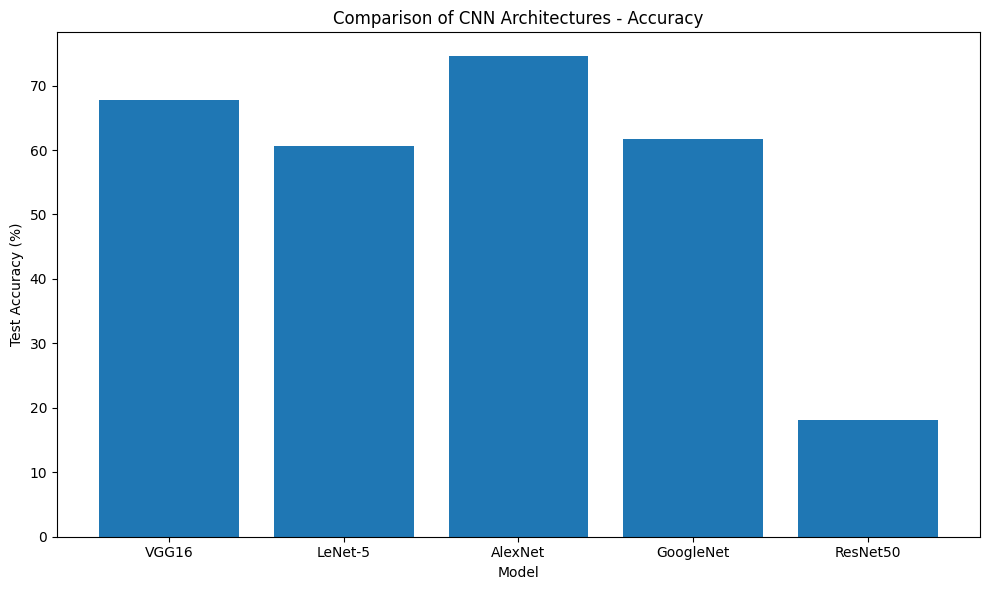

In [36]:
plt.figure(figsize=(10,6))
plt.bar(model_names,model_accuracies)
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of CNN Architectures - Accuracy")
plt.tight_layout()
plt.savefig("images/model_comparison_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

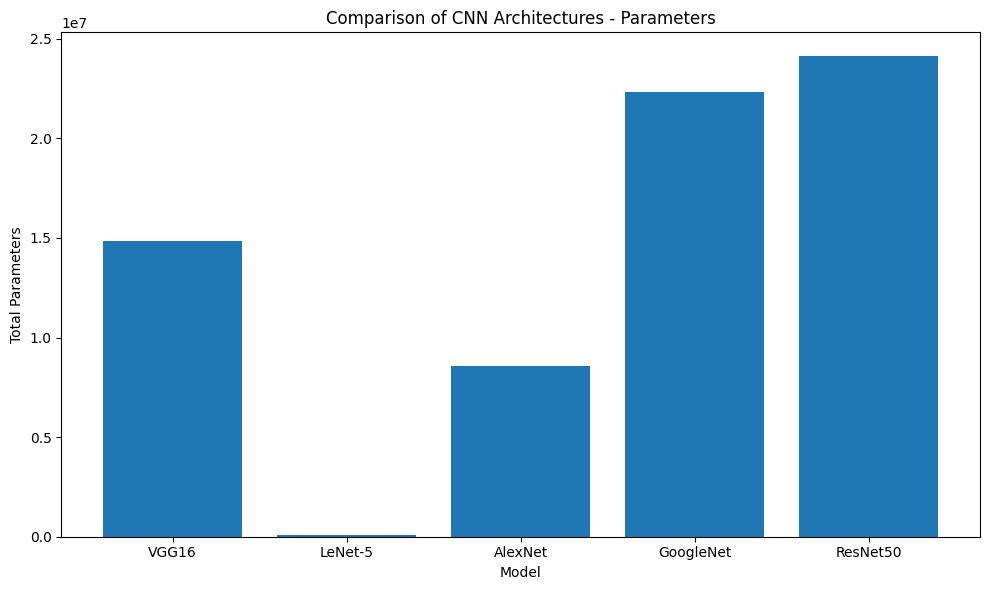

In [37]:
plt.figure(figsize=(10,6))
plt.bar(model_names,model_parameters)
plt.xlabel("Model")
plt.ylabel("Total Parameters")
plt.title("Comparison of CNN Architectures - Parameters")
plt.tight_layout()
plt.savefig("images/model_comparison_parameters.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

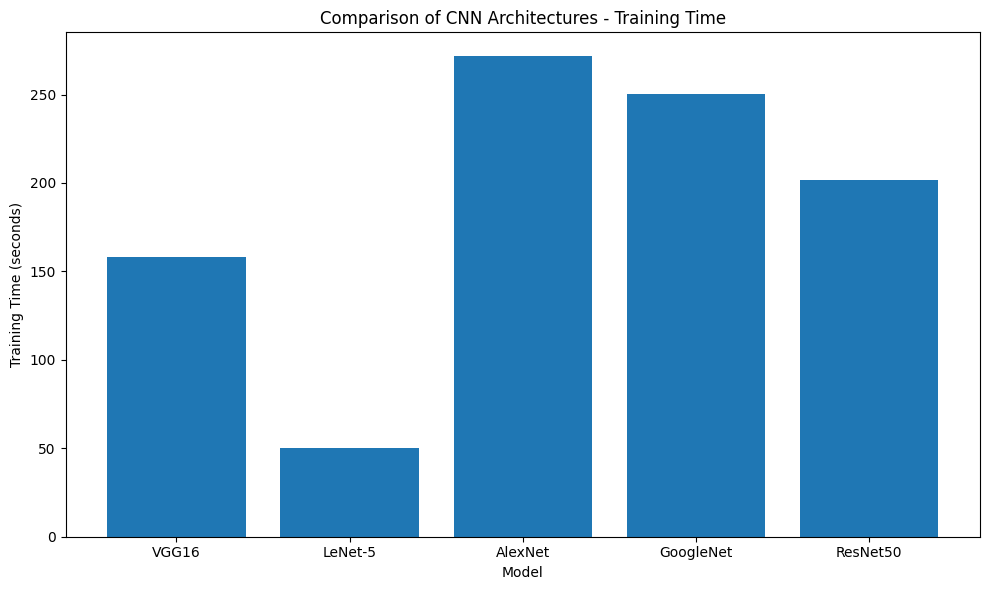

In [38]:
plt.figure(figsize=(10,6))
plt.bar(model_names,model_times)
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Comparison of CNN Architectures - Training Time")
plt.tight_layout()
plt.savefig("images/model_comparison_training_time.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()